<a href="https://colab.research.google.com/github/samarkumar11/Loan-Prediction-Using-Machine-Learning/blob/main/Heart_Disease_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv( '/content/Heart_Disease_Prediction.csv')

In [4]:
df.head(10)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
5,65,1,4,120,177,0,0,140,0,0.4,1,0,7,Absence
6,56,1,3,130,256,1,2,142,1,0.6,2,1,6,Presence
7,59,1,4,110,239,0,2,142,1,1.2,2,1,7,Presence
8,60,1,4,140,293,0,2,170,0,1.2,2,2,7,Presence
9,63,0,4,150,407,0,2,154,0,4.0,2,3,7,Presence


In [5]:
df.drop(['EKG results','Slope of ST',], axis=1, inplace=True)

In [6]:
df.head(10)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,109,0,2.4,3,3,Presence
1,67,0,3,115,564,0,160,0,1.6,0,7,Absence
2,57,1,2,124,261,0,141,0,0.3,0,7,Presence
3,64,1,4,128,263,0,105,1,0.2,1,7,Absence
4,74,0,2,120,269,0,121,1,0.2,1,3,Absence
5,65,1,4,120,177,0,140,0,0.4,0,7,Absence
6,56,1,3,130,256,1,142,1,0.6,1,6,Presence
7,59,1,4,110,239,0,142,1,1.2,1,7,Presence
8,60,1,4,140,293,0,170,0,1.2,2,7,Presence
9,63,0,4,150,407,0,154,0,4.0,3,7,Presence


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   Max HR                   270 non-null    int64  
 7   Exercise angina          270 non-null    int64  
 8   ST depression            270 non-null    float64
 9   Number of vessels fluro  270 non-null    int64  
 10  Thallium                 270 non-null    int64  
 11  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(10), object(1)
memory usage: 25.4+ KB


In [72]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
Exercise angina,0
ST depression,0
Number of vessels fluro,0
Thallium,0
Heart Disease,0


In [71]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,Exercise angina,ST depression,Number of vessels fluro,Thallium,Heart Disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.329630,1.05000,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.470952,1.14521,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.00000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.00000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,0.80000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,1.000000,1.60000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,6.20000,3.000000,7.000000,1.000000


In [77]:
df['Heart Disease'] = df['Heart Disease'].replace({'Presence': 1, 'Absence': 0})

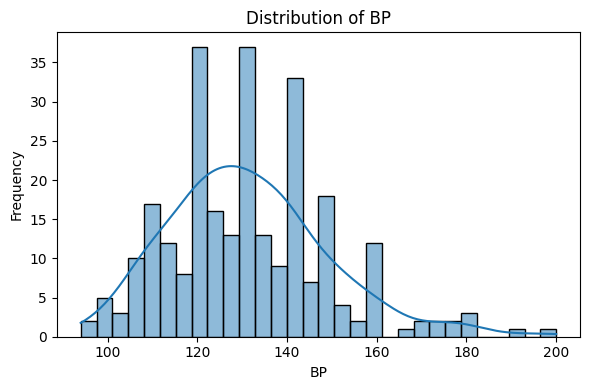

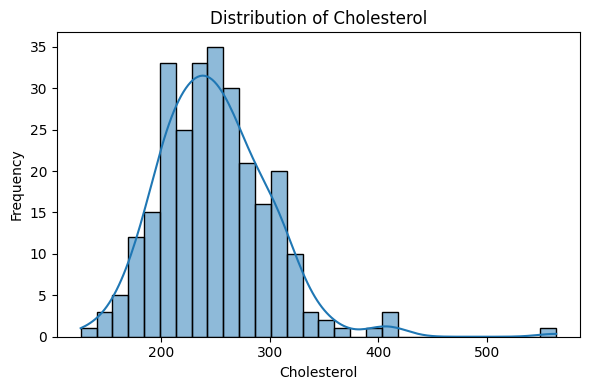

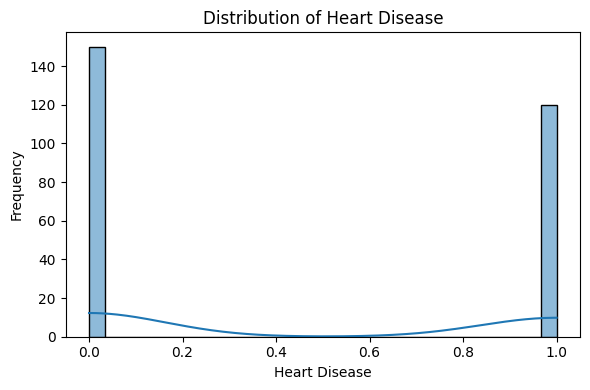

In [75]:
numerical_columns = ['BP','Cholesterol','Heart Disease']
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde = True , bins = 30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

<Axes: xlabel='Age', ylabel='count'>

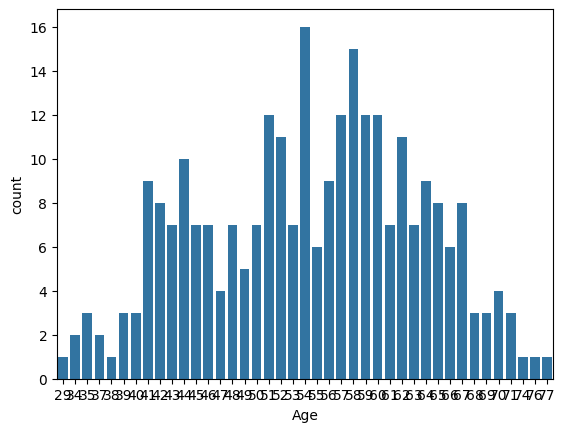

In [76]:
sns.countplot(x = df['Age'])

In [10]:
df['Heart Disease'].value_counts()

,count
Heart Disease,
Absence,150
Presence,120


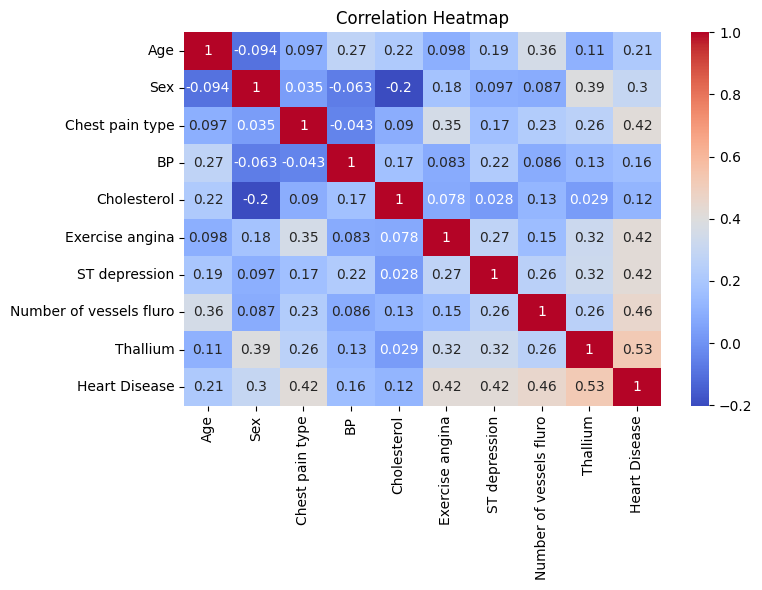

In [32]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [15]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'Max HR', 'Exercise angina', 'ST depression', 'Number of vessels fluro',
       'Thallium', 'Heart Disease'],
      dtype='object')

In [18]:
df.drop(['FBS over 120','Max HR'], axis=1, inplace=True)

In [34]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
   'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
         'Exercise angina', 'ST depression', 'Number of vessels fluro',
       'Thallium', 'Heart Disease',
]

# Calculate Pearson correlation
correlations = {
    feature: pearsonr(df[feature], df['Heart Disease'])[0]
    for feature in selected_features
}

# Convert to DataFrame for display
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])

# Show the results
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
9,Heart Disease,1.000000
8,Thallium,0.525020
7,Number of vessels fluro,0.455336
5,Exercise angina,0.419303
6,ST depression,0.417967
2,Chest pain type,0.417436
1,Sex,0.297721
0,Age,0.212322
3,BP,0.155383
4,Cholesterol,0.118021


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df.drop("Heart Disease", axis=1)
y = df["Heart Disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


#Logistic_Regression

In [42]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8148148148148148


In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [45]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

#KNeighborsClassifier

In [46]:
from sklearn.neighbors import KNeighborsClassifier

In [47]:
knn_model = KNeighborsClassifier(n_neighbors= 5)
knn_model.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [48]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [49]:
accuracy_score(y_test,y_pred_knn)

0.8333333333333334

#GaussianNB

In [52]:
from sklearn.naive_bayes import GaussianNB

In [53]:
model_NB = GaussianNB()
model_NB.fit(X_train,y_train)

GaussianNB()

In [54]:
y_pred_NB = model_NB.predict(X_test)

In [55]:
y_pred_NB

array([0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1])

In [56]:
accuracy_score(y_test,y_pred_NB)

0.7962962962962963

#DecisionTreeClassifier

In [57]:
from sklearn.tree import DecisionTreeClassifier
model_DT = DecisionTreeClassifier(random_state=42)
model_DT.fit(X_train_scaled,y_train)

DecisionTreeClassifier(random_state=42)

In [58]:
y_pred_DT = model_DT.predict(X_test_scaled)

In [59]:
accuracy_score(y_test,y_pred_DT)

0.7777777777777778

#SVC

In [60]:
from sklearn.svm import SVC
model_svm = SVC(kernel = 'linear')
model_svm.fit(X_train_scaled, y_train)

SVC(kernel='linear')

In [61]:
y_pred_svc = model_svm.predict(X_test_scaled)

In [62]:
accuracy_score(y_test,y_pred_svc)

0.8148148148148148

In [63]:
df

,Age,Sex,Chest pain type,BP,Cholesterol,Exercise angina,ST depression,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2.4,3,3,1
1,67,0,3,115,564,0,1.6,0,7,0
2,57,1,2,124,261,0,0.3,0,7,1
3,64,1,4,128,263,1,0.2,1,7,0
4,74,0,2,120,269,1,0.2,1,3,0
...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,0,0.5,0,7,0
266,44,1,2,120,263,0,0.0,0,7,0
267,56,0,2,140,294,0,1.3,0,3,0
268,57,1,4,140,192,0,0.4,0,6,0


#Now  Cross Validation

In [64]:
X = df.drop('Heart Disease',axis = 1)
y = df['Heart Disease']

In [65]:
from sklearn.model_selection import cross_val_score

In [66]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [67]:
scores = cross_val_score(model_svm,X_scaled,y,cv = 5,scoring= 'accuracy')
print(scores)

[0.7962963  0.77777778 0.88888889 0.77777778 0.85185185]


In [68]:
print(scores.mean())

0.8185185185185185
